In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('/content/Churn_Modelling.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
data.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
data.shape

(10000, 14)

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data = pd.read_csv('/content/Churn_Modelling.csv')
geography = pd.get_dummies(data['Geography'] , drop_first=True)


In [ ]:
gender = pd.get_dummies(data['Gender'] , drop_first=True)

In [ ]:
data.drop(['Geography' , 'Gender'] , axis=1 , inplace=True, errors='ignore')

In [ ]:
data = pd.concat([data , geography , gender] , axis=1)
data

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Germany,Spain,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,9997,15569892,Johnstone,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,9998,15584532,Liu,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,9999,15682355,Sabbatini,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(data.drop(['RowNumber' , 'CustomerId' , 'Surname' , 'Exited'] , axis=1) , data['Exited'] , test_size=0.2 , random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
x_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [ ]:
x_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [ ]:
x_train.shape , x_test.shape

((8000, 11), (2000, 11))

In [ ]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , LeakyReLU , Dropout

In [ ]:
classifier = Sequential()
#input layer
classifier.add(Dense(units=6 , activation='relu' , input_dim=11))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [ ]:
classifier.add(Dense(units=6 , activation='relu'))
classifier.add(Dropout(0.3))

In [ ]:
# second hidden layer
classifier.add(Dense(units=6 , activation='relu'))

In [ ]:
# Output layer
classifier.add(Dense(units=1 , activation='sigmoid'))

In [ ]:
classifier.compile(optimizer='adam' ,loss='binary_crossentropy' , metrics=['accuracy'] )

In [ ]:
model_history = classifier.fit(x_train , y_train , validation_split=0.33 , batch_size=10 , epochs=100 , callbacks = early_stopping )

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7404 - loss: 0.5888 - val_accuracy: 0.7910 - val_loss: 0.5024
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7960 - loss: 0.4895 - val_accuracy: 0.7925 - val_loss: 0.4613
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8037 - loss: 0.4638 - val_accuracy: 0.8129 - val_loss: 0.4443
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8050 - loss: 0.4455 - val_accuracy: 0.8205 - val_loss: 0.4342
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8160 - loss: 0.4340 - val_accuracy: 0.8262 - val_loss: 0.4269
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8175 - loss: 0.4270 - val_accuracy: 0.8292 - val_loss: 0.4199
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8265 - loss: 0.4132 - val_accuracy: 0.8338 - val_loss: 0.4112
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8339 - loss: 0.4024 - val_accu

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

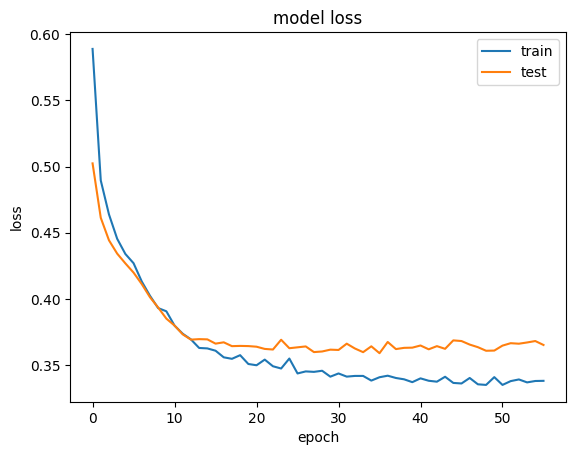

In [ ]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train' , 'test'])
plt.show()

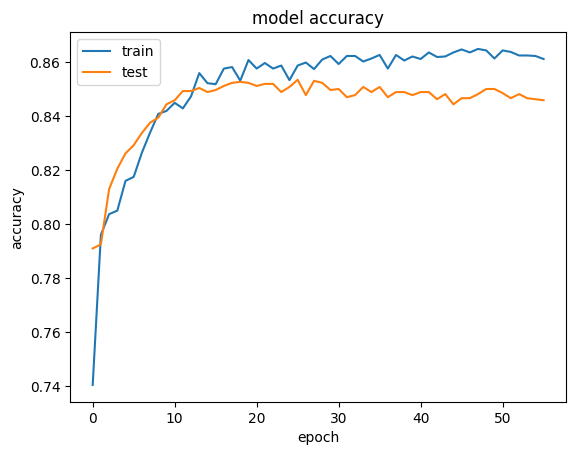

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train' , 'test'])
plt.show()

In [ ]:
y_pred = classifier.predict(x_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Axes: >

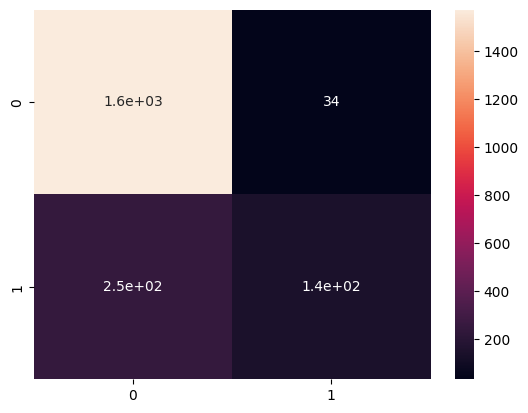

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred)
import seaborn as sns
sns.heatmap(cm , annot=True)

In [ ]:
# Calculating accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred , y_test)
score

0.8585

In [ ]:
# get the weights
classifier.get_weights()

[array([[ 0.02115058,  0.0072456 ,  0.01964438,  0.17034265,  0.01249587,
          0.01048703],
        [-0.879492  , -0.19080134,  0.37609047, -0.77157646,  0.15393019,
         -0.96172166],
        [-0.07680736, -0.03331744, -0.0223599 ,  0.26387417, -0.09821761,
         -0.1607542 ],
        [ 0.1521236 , -0.1564302 ,  0.0686611 , -0.27357206,  0.6614427 ,
          0.06596374],
        [-0.34248048, -1.4681327 ,  0.13503881, -0.16977592,  1.4390045 ,
         -0.18010366],
        [ 0.03550807,  0.02456378,  0.1645183 , -0.00737823, -0.00456128,
         -0.09585807],
        [-0.73167545, -0.46676072,  0.7944152 , -0.58559   , -0.3430948 ,
          0.576951  ],
        [ 0.10838138,  0.11304758,  0.40590054,  0.01883722,  0.1889923 ,
         -0.07532807],
        [ 0.11754166,  0.25467855,  0.11822205, -0.27592653, -0.13790391,
         -0.1671586 ],
        [ 0.04552354,  0.02041575,  0.09873246, -0.11491515,  0.09096871,
         -0.02408261],
        [-0.19454545,  0.03297